# b(ii) Risk Severity Among Flagged Patients

This notebook prioritizes already-flagged ICU patient-hours by estimating short-term deterioration risk.

Because the dataset does not include a direct septic shock label, we use a **proxy rapid deterioration outcome**:
- deterioration in next 1-6 hours if any future hour meets
  - `(MAP < 65 and Lactate >= 2.0)` OR `(SBP < 90 and Lactate >= 2.0)`

This approximates hemodynamic instability with hyperlactatemia and is used only for risk-severity ranking.

In [32]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, classification_report, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [33]:
# Config
ROOT = Path.cwd().resolve()
if ROOT.name != "safe_dss":
    ROOT = ROOT.parent

DATA_PATH = ROOT / "preprocessing" / "imputed_dataset.csv"
OUT_DIR = ROOT / "analysis" / "outputs" / "risk_severity_flagged"

# Flagging threshold is learned from stage-1 risk predictions on train split
FLAG_PERCENTILE = 0.80   # top 20% highest stage-1 risk in train

print("Data:", DATA_PATH)
print("Output:", OUT_DIR)
print("Flag percentile:", FLAG_PERCENTILE)

Data: /Users/eugeneho/Desktop/safe_dss/preprocessing/imputed_dataset.csv
Output: /Users/eugeneho/Desktop/safe_dss/analysis/outputs/risk_severity_flagged
Flag percentile: 0.8


In [34]:
def load_and_clean(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    for c in df.columns:
        if c == "patient_id":
            continue
        df[c] = pd.to_numeric(df[c], errors="coerce")

    if "EtCO2" in df.columns and df["EtCO2"].isna().all():
        df = df.drop(columns=["EtCO2"])

    for c in ("Unit1", "Unit2"):
        if c in df.columns and df[c].isna().any():
            df[c] = df[c].fillna(df[c].median())
    return df


def add_pattern_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(["patient_id", "ICULOS"]).copy()
    g = df.groupby("patient_id", sort=False)

    roll_cols = ["MAP", "HR", "Lactate", "Resp", "WBC", "Temp", "Creatinine", "Glucose"]
    roll_cols = [c for c in roll_cols if c in df.columns]

    for c in roll_cols:
        df[f"{c}_roll3"] = g[c].transform(lambda s: s.rolling(window=3, min_periods=1).mean())

    for c in ["MAP", "Lactate", "HR"]:
        if c in df.columns:
            df[f"{c}_delta1"] = g[c].diff().fillna(0.0)
    return df


def add_stage1_label(df: pd.DataFrame) -> pd.DataFrame:
    # Stage-1: same 6-12h future sepsis onset label used in b(i)
    df = df.sort_values(["patient_id", "ICULOS"]).copy()
    g = df.groupby("patient_id", sort=False)["SepsisLabel"]
    fut = pd.concat([g.shift(-k).rename(f"_f{k}") for k in range(6, 13)], axis=1)
    df["y_onset_6_12h"] = fut.max(axis=1, skipna=False)
    df["_future6_12_ok"] = fut.notna().all(axis=1)
    return df


def add_deterioration_proxy_label(df: pd.DataFrame) -> pd.DataFrame:
    # Stage-2 target: rapid deterioration in next 1-6h
    df = df.sort_values(["patient_id", "ICULOS"]).copy()
    g = df.groupby("patient_id", sort=False)

    conds = []
    observed = []
    for k in range(1, 7):
        map_f = g["MAP"].shift(-k)
        sbp_f = g["SBP"].shift(-k)
        lac_f = g["Lactate"].shift(-k)

        shock_like = ((map_f < 65) & (lac_f >= 2.0)) | ((sbp_f < 90) & (lac_f >= 2.0))
        conds.append(shock_like.rename(f"_d{k}"))
        observed.append(map_f.notna() & sbp_f.notna() & lac_f.notna())

    cdf = pd.concat(conds, axis=1)
    odf = pd.concat(observed, axis=1)
    df["y_deterioration_1_6h"] = cdf.max(axis=1, skipna=False)
    df["_future1_6_ok"] = odf.any(axis=1)
    return df


def build_matrix(df: pd.DataFrame, target_col: str):
    drop_cols = {
        "patient_id", "SepsisLabel", "y_onset_6_12h", "_future6_12_ok",
        "y_deterioration_1_6h", "_future1_6_ok"
    }
    X = df.drop(columns=[c for c in drop_cols if c in df.columns])
    y = df[target_col].astype(int).values
    groups = df["patient_id"].values
    return X, y, groups

In [35]:
# Build base table
df = load_and_clean(DATA_PATH)
df = add_pattern_features(df)
df = add_stage1_label(df)
df = add_deterioration_proxy_label(df)

# Keep rows where both labels are observable and where patient is not currently septic
df = df[df["_future6_12_ok"] & df["_future1_6_ok"] & (df["SepsisLabel"] == 0)].copy()

print("Rows after eligibility:", len(df))
print("Stage-1 onset prevalence:", round(df["y_onset_6_12h"].mean(), 4))
print("Stage-2 deterioration prevalence (pre-flag):", round(df["y_deterioration_1_6h"].mean(), 4))

Rows after eligibility: 129557
Stage-1 onset prevalence: 0.0996
Stage-2 deterioration prevalence (pre-flag): 0.0658


In [36]:
# Split once by patient for final reporting
groups = df["patient_id"].values
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
idx_tr, idx_te = next(gss.split(df, df["y_onset_6_12h"], groups))

train_df = df.iloc[idx_tr].copy()
test_df = df.iloc[idx_te].copy()

# Stage-1 model on train: predicts 6-12h sepsis onset
X1_tr, y1_tr, _ = build_matrix(train_df, "y_onset_6_12h")
X1_te, y1_te, _ = build_matrix(test_df, "y_onset_6_12h")
feature_names = list(X1_tr.columns)

pre = ColumnTransformer([("num", StandardScaler(), feature_names)], remainder="drop")
stage1 = Pipeline([
    ("prep", pre),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs")),
])
stage1.fit(X1_tr, y1_tr)

train_df["stage1_risk"] = stage1.predict_proba(X1_tr)[:, 1]
test_df["stage1_risk"] = stage1.predict_proba(X1_te)[:, 1]

flag_threshold = float(train_df["stage1_risk"].quantile(FLAG_PERCENTILE))
train_flagged = train_df[train_df["stage1_risk"] >= flag_threshold].copy()
test_flagged = test_df[test_df["stage1_risk"] >= flag_threshold].copy()

print("Flag threshold:", round(flag_threshold, 4))
print("Flagged train rows:", len(train_flagged), "(", round(len(train_flagged)/len(train_df), 3), ")")
print("Flagged test rows:", len(test_flagged), "(", round(len(test_flagged)/len(test_df), 3), ")")
print("Stage-2 prevalence in flagged train:", round(train_flagged["y_deterioration_1_6h"].mean(), 4))
print("Stage-2 prevalence in flagged test:", round(test_flagged["y_deterioration_1_6h"].mean(), 4))

Flag threshold: 0.5742
Flagged train rows: 20517 ( 0.2 )
Flagged test rows: 5793 ( 0.215 )
Stage-2 prevalence in flagged train: 0.0644
Stage-2 prevalence in flagged test: 0.0785


In [37]:
# Stage-2 model among flagged patients
X2_tr, y2_tr, g2_tr = build_matrix(train_flagged, "y_deterioration_1_6h")
X2_te, y2_te, _ = build_matrix(test_flagged, "y_deterioration_1_6h")
feature_names_2 = list(X2_tr.columns)

# CV on flagged cohort (train only)
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
fold_metrics = []
coef_accum = []

for fold, (tr, va) in enumerate(sgkf.split(X2_tr, y2_tr, g2_tr)):
    Xtr, Xva = X2_tr.iloc[tr], X2_tr.iloc[va]
    ytr, yva = y2_tr[tr], y2_tr[va]

    pre2 = ColumnTransformer([("num", StandardScaler(), feature_names_2)], remainder="drop")
    logit2 = Pipeline([
        ("prep", pre2),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs")),
    ])
    logit2.fit(Xtr, ytr)
    p_logit = logit2.predict_proba(Xva)[:, 1]
    fold_metrics.append({
        "fold": fold,
        "model": "logistic_l2",
        "auroc": float(roc_auc_score(yva, p_logit)),
        "auprc": float(average_precision_score(yva, p_logit)),
    })
    coef_accum.append(np.abs(logit2.named_steps["clf"].coef_.ravel()))

    hgb2 = HistGradientBoostingClassifier(
        max_depth=6,
        max_iter=200,
        learning_rate=0.06,
        random_state=42,
        class_weight="balanced",
    )
    hgb2.fit(Xtr, ytr)
    p_hgb = hgb2.predict_proba(Xva)[:, 1]
    fold_metrics.append({
        "fold": fold,
        "model": "hist_gbrt",
        "auroc": float(roc_auc_score(yva, p_hgb)),
        "auprc": float(average_precision_score(yva, p_hgb)),
    })

metrics_df = pd.DataFrame(fold_metrics)
metrics_summary = metrics_df.groupby("model")[["auroc", "auprc"]].agg(["mean", "std"])
metrics_summary

auroc               auprc          
                 mean       std      mean       std
model                                              
hist_gbrt    0.953001  0.015757  0.641814  0.071077
logistic_l2  0.933311  0.017508  0.489889  0.097543

Holdout Logistic AUROC: 0.9167
Holdout Logistic AUPRC: 0.4692
Holdout HGB AUROC: 0.9422
Holdout HGB AUPRC: 0.675


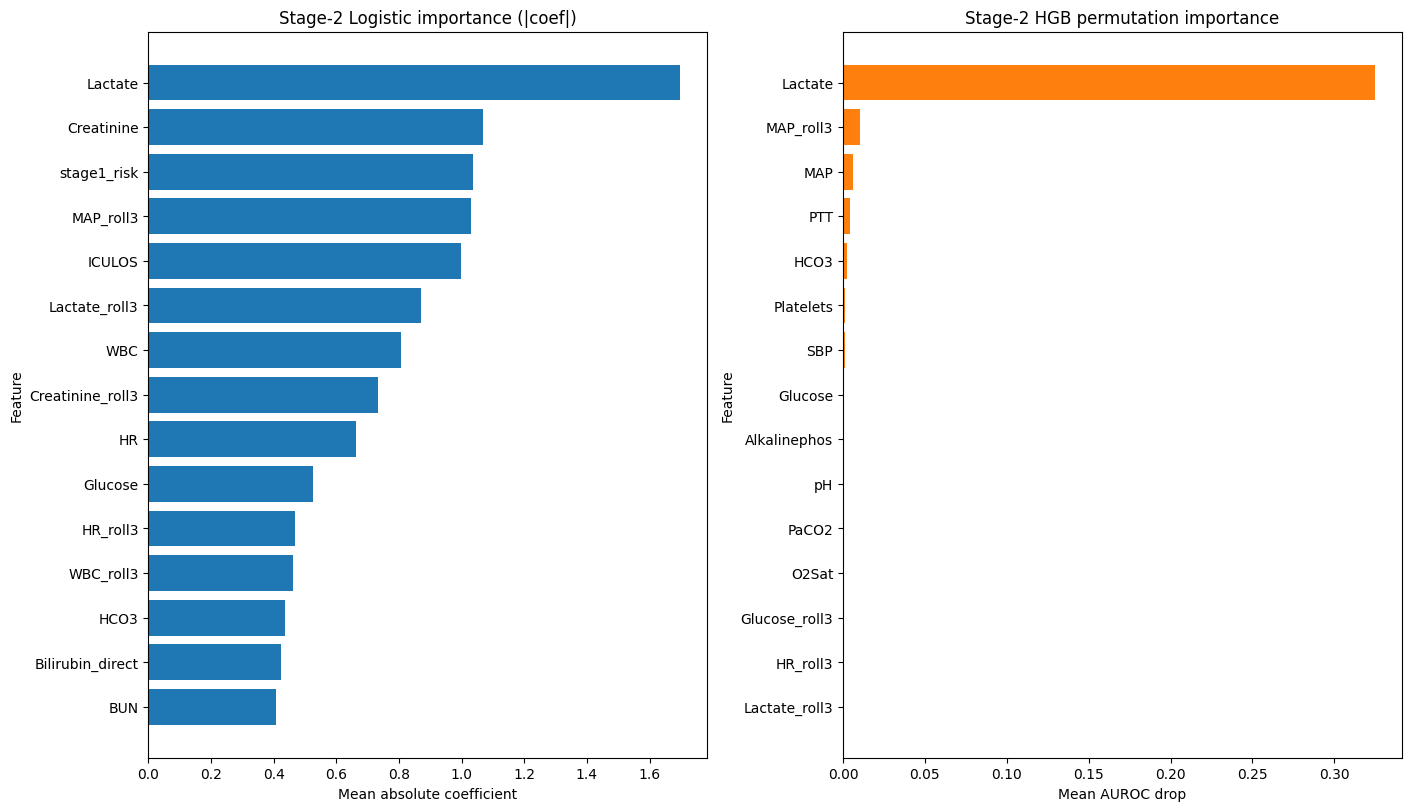

,feature,mean_abs_coef_cv
21,Lactate,1.698895
18,Creatinine,1.068884
50,stage1_risk,1.034937
39,MAP_roll3,1.031284
38,ICULOS,0.997573
41,Lactate_roll3,0.869173
30,WBC,0.807446
45,Creatinine_roll3,0.731574
0,HR,0.662589
20,Glucose,0.526689


,feature,delta_roc_auc_mean
21,Lactate,0.324893
39,MAP_roll3,0.010258
4,MAP,0.006298
29,PTT,0.004169
8,HCO3,0.002382
32,Platelets,0.001141
3,SBP,0.000944
20,Glucose,0.000579
15,Alkalinephos,0.000484
10,pH,0.000393


In [38]:
# Final stage-2 fit + holdout + importance + plots
pre2 = ColumnTransformer([("num", StandardScaler(), feature_names_2)], remainder="drop")
final_logit2 = Pipeline([
    ("prep", pre2),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs")),
])
final_logit2.fit(X2_tr, y2_tr)
p_logit_te = final_logit2.predict_proba(X2_te)[:, 1]

final_hgb2 = HistGradientBoostingClassifier(
    max_depth=6,
    max_iter=200,
    learning_rate=0.06,
    random_state=42,
    class_weight="balanced",
)
final_hgb2.fit(X2_tr, y2_tr)
p_hgb_te = final_hgb2.predict_proba(X2_te)[:, 1]

print("Holdout Logistic AUROC:", round(roc_auc_score(y2_te, p_logit_te), 4))
print("Holdout Logistic AUPRC:", round(average_precision_score(y2_te, p_logit_te), 4))
print("Holdout HGB AUROC:", round(roc_auc_score(y2_te, p_hgb_te), 4))
print("Holdout HGB AUPRC:", round(average_precision_score(y2_te, p_hgb_te), 4))

coef_mean = np.mean(coef_accum, axis=0)
logit_imp = pd.DataFrame({
    "feature": feature_names_2,
    "mean_abs_coef_cv": coef_mean,
}).sort_values("mean_abs_coef_cv", ascending=False)

rng = np.random.RandomState(42)
n_perm = min(8000, len(X2_te))
perm_pos = rng.choice(len(X2_te), size=n_perm, replace=False)
X_perm = X2_te.iloc[perm_pos]
y_perm = y2_te[perm_pos]

perm_res = permutation_importance(
    final_hgb2,
    X_perm,
    y_perm,
    n_repeats=5,
    random_state=42,
    scoring="roc_auc",
    n_jobs=1,
)
perm_imp = pd.DataFrame({
    "feature": feature_names_2,
    "delta_roc_auc_mean": perm_res.importances_mean,
}).sort_values("delta_roc_auc_mean", ascending=False)

k = 15
plot_logit = logit_imp.head(k).sort_values("mean_abs_coef_cv", ascending=True)
plot_perm = perm_imp.head(k).sort_values("delta_roc_auc_mean", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 8), constrained_layout=True)
axes[0].barh(plot_logit["feature"], plot_logit["mean_abs_coef_cv"], color="#1f77b4")
axes[0].set_title("Stage-2 Logistic importance (|coef|)")
axes[0].set_xlabel("Mean absolute coefficient")
axes[0].set_ylabel("Feature")

axes[1].barh(plot_perm["feature"], plot_perm["delta_roc_auc_mean"], color="#ff7f0e")
axes[1].set_title("Stage-2 HGB permutation importance")
axes[1].set_xlabel("Mean AUROC drop")
axes[1].set_ylabel("Feature")
plt.show()

display(logit_imp.head(k))
display(perm_imp.head(k))

### b(iii) Profiles among flagged patients (interpretation from Stage 2)

**Stage 2** ranks patients already flagged by Stage 1 for short-term deterioration. **Profile insight** uses the same cohort: demographics, units, timing, and physiology. The **Random Forest** below reports holdout metrics and a **Gini feature-importance** bar chart (plus CSV), not SHAP.

---

Run after `X2_tr`, `X2_te`, `y2_te`, `feature_names_2` exist.

Stage-2 RF holdout AUROC: 0.9542
Stage-2 RF holdout AUPRC: 0.686


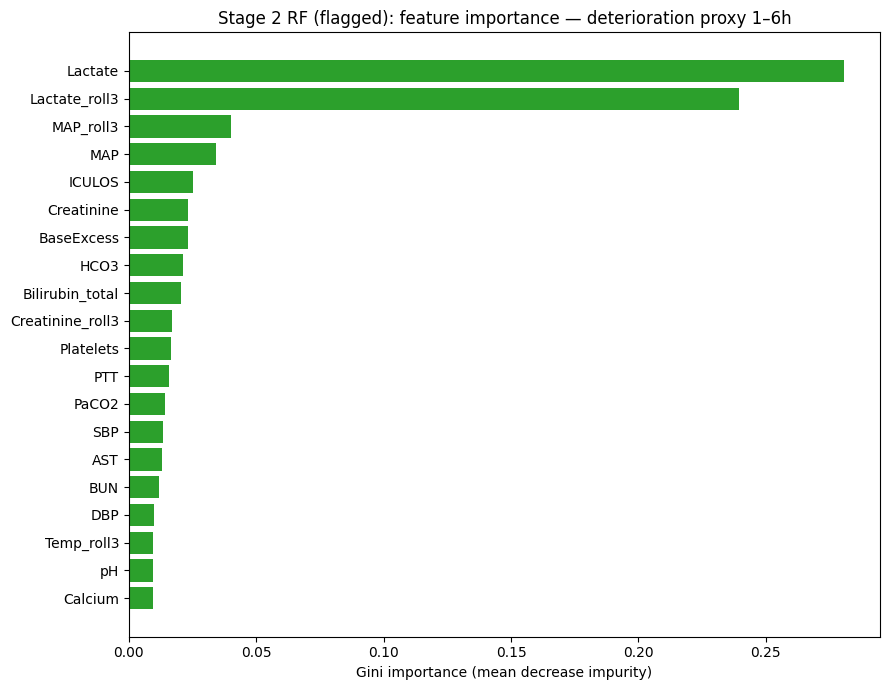

Wrote /Users/eugeneho/Desktop/safe_dss/analysis/outputs/risk_severity_flagged/metrics_rf_stage2.json and /Users/eugeneho/Desktop/safe_dss/analysis/outputs/risk_severity_flagged/rf_feature_importance_stage2.csv


In [39]:
# Random Forest (Stage 2, flagged cohort) + Gini feature importance
from sklearn.ensemble import RandomForestClassifier

rf_stage2 = RandomForestClassifier(
    n_estimators=400,
    max_depth=14,
    min_samples_leaf=10,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)
rf_stage2.fit(X2_tr, y2_tr)
p2_rf_te = rf_stage2.predict_proba(X2_te)[:, 1]
print("Stage-2 RF holdout AUROC:", round(roc_auc_score(y2_te, p2_rf_te), 4))
print("Stage-2 RF holdout AUPRC:", round(average_precision_score(y2_te, p2_rf_te), 4))

rf_imp2 = (
    pd.DataFrame({"feature": feature_names_2, "importance": rf_stage2.feature_importances_})
    .sort_values("importance", ascending=True)
)
k_rf = min(20, len(rf_imp2))
plot_rf = rf_imp2.tail(k_rf)
plt.figure(figsize=(9, 7))
plt.barh(plot_rf["feature"], plot_rf["importance"], color="#2ca02c")
plt.xlabel("Gini importance (mean decrease impurity)")
plt.title("Stage 2 RF (flagged): feature importance — deterioration proxy 1–6h")
plt.tight_layout()
plt.show()

OUT_DIR.mkdir(parents=True, exist_ok=True)
rf_imp2.sort_values("importance", ascending=False).to_csv(OUT_DIR / "rf_feature_importance_stage2.csv", index=False)
with open(OUT_DIR / "metrics_rf_stage2.json", "w") as f:
    json.dump(
        {
            "holdout_auroc_rf": float(roc_auc_score(y2_te, p2_rf_te)),
            "holdout_auprc_rf": float(average_precision_score(y2_te, p2_rf_te)),
        },
        f,
        indent=2,
    )
print("Wrote", OUT_DIR / "metrics_rf_stage2.json", "and", OUT_DIR / "rf_feature_importance_stage2.csv")